# Band8 NAC helix-packing figures

This notebook only draws the final, intuitive evidence from
`results/summary_bin_metrics.csv`. Numerical trajectory analysis is performed
separately by `analyze_band8.py`.

**Question.** Does the helical NAC region show stronger axial alignment and a
broad antiparallel-like contact preference at particular cluster sizes?

**Final evidence.** The signed-angle distribution is retained to show the full geometry, followed by two intuitive percentages: axially aligned pairs and broad
anti-diagonal contact preference. Antiparallel share is retained in the table
as an important diagnostic, but not promoted to a main figure.

## Definitions

- Axially aligned: $|\cos	heta|\geq0.5$, where $	heta$ is the angle between
  signed PCA axes of NAC residues 61–95.
- Antiparallel share: among aligned pairs,
  $N(\cos	heta\leq-0.5)/[N(\cos	heta\leq-0.5)+N(\cos	heta\geq0.5)]$.
  A value of 50% means no directional bias.
- Anti-diagonal preference:
  $100(\langle q_A
angle/\langle q_P
angle-1)$, where $q_A$ and $q_P$ are
  the mean smooth contacts in the strict <8-residue anti-diagonal and parallel bands.
  Residue offsets equal to 8 are excluded.
  Zero means equal contact strength.

Clusters are connected components of the <8 Å whole-chain BB network. NAC
pairs must be strictly closer than 8 Å and belong to the same <8 Å component.

Each percentage is calculated within each independent trajectory first. The
plotted mean and SEM are then calculated across the three trajectories.

- Signed-cos distribution: each independent trajectory is normalized to 100%
  over 40 bins of width 0.05. The plotted curve is the mean probability per
  bin across trajectories, with a shaded trajectory-level SEM. This is a
  probability per bin—not a probability density.

In [2]:
# =========================
# 统一论文图的风格和尺寸, 方便后续拼接
# =========================
import os
from pathlib import Path
import json

# Locate the analysis directory whether the notebook is launched from the
# project root or from Analysis/helix_packing. This still works after
# results/ has been deleted.
_candidates = [Path.cwd(), Path.cwd() / "Analysis" / "helix_packing"]
HERE = next(
    (
        path for path in _candidates
        if (path / "datasets.csv").exists() and (path / "plot_band8.ipynb").exists()
    ),
    None,
)
if HERE is None:
    raise FileNotFoundError(
        "Cannot locate Analysis/helix_packing. Launch this notebook from the "
        "project root or from Analysis/helix_packing."
    )
RESULTS_DIR = HERE / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
REQUIRED_RESULT_FILES = (
    "summary_bin_metrics.csv",
    "replicate_bin_metrics.csv",
    "cos_histogram.csv",
    "analysis_config.json",
)


def require_result_files():
    missing = [RESULTS_DIR / name for name in REQUIRED_RESULT_FILES if not (RESULTS_DIR / name).exists()]
    if missing:
        missing_text = "\n".join(f"  - {path}" for path in missing)
        raise FileNotFoundError(
            "Missing analysis result files. Regenerate them before plotting with:\n"
            f"  /home/jychen/anaconda3/envs/mdanalysis/bin/python {HERE / 'analyze_band8.py'}\n\n"
            f"Missing files:\n{missing_text}"
        )


require_result_files()

MPLCONFIGDIR = Path(os.environ.get("MPLCONFIGDIR", "/tmp/matplotlib-jychen"))
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# 字体设置：只需要改这里
# =========================
ARIAL_TTF_PATH = "/data/jychen/package/Arial/arial.ttf"
USE_ARIAL_TTF = True

_PUB_FONT_NAME = None


def load_pub_font():
    """手动加载 Arial.ttf，并返回字体在 matplotlib 中识别到的真实名称。"""
    global _PUB_FONT_NAME
    if _PUB_FONT_NAME is not None:
        return _PUB_FONT_NAME
    if USE_ARIAL_TTF:
        if not os.path.exists(ARIAL_TTF_PATH):
            raise FileNotFoundError(f"找不到 Arial 字体文件: {ARIAL_TTF_PATH}")
        fm.fontManager.addfont(ARIAL_TTF_PATH)
        _PUB_FONT_NAME = fm.FontProperties(fname=ARIAL_TTF_PATH).get_name()
    else:
        _PUB_FONT_NAME = "Arial"
    print(f"Using font: {_PUB_FONT_NAME}")
    return _PUB_FONT_NAME


def mm_to_inch(mm):
    return mm / 25.4


FIG_SIZE = {
    "single":  90,
    "double": 180,
}

FIG_PRESETS = {
    "single_small":  ("single", 60),
    "single_medium": ("single", 75),
    "double_short":  ("double", 70),
    "double_medium": ("double", 100),
    "double_large":  ("double", 140),
}

_SHARED_FONT_SIZES = {
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
}


def set_pub_style():
    pub_font = load_pub_font()
    base = {
        "font.family": pub_font,
        "font.sans-serif": [pub_font, "Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
        "font.weight": "normal",
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "axes.linewidth": 1.5,
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 4.5,
        "ytick.major.size": 4.5,
        "xtick.minor.size": 2.8,
        "ytick.minor.size": 2.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "lines.linewidth": 1.7,
        "patch.linewidth": 1.3,
        "legend.frameon": False,
        "legend.handlelength": 1.5,
        "legend.handletextpad": 0.4,
        "axes.unicode_minus": False,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "savefig.dpi": 600,
        "figure.dpi": 120,
    }
    base.update(_SHARED_FONT_SIZES)
    mpl.rcParams.update(base)


def new_figure(mode="single", height_mm=65):
    set_pub_style()
    width_mm = FIG_SIZE[mode]
    fig, ax = plt.subplots(
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm))
    )
    return fig, ax


def new_subplots(nrows, ncols, preset="double_medium", **kwargs):
    set_pub_style()
    mode, height_mm = FIG_PRESETS[preset]
    width_mm = FIG_SIZE[mode]
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(mm_to_inch(width_mm), mm_to_inch(height_mm)),
        **kwargs
    )
    return fig, axes


def savefig_pub(fig, filename, dpi=600, tight=False):
    if tight:
        fig.savefig(filename, dpi=dpi, bbox_inches="tight", pad_inches=0.02)
    else:
        fig.savefig(filename, dpi=dpi)


# 应用统一风格模板
set_pub_style()

# =========================
# 项目特定设置
# =========================

COLORS = {"IDP50": "#4C78A8", "Hel50": "#E45756"}
LABELS = {"IDP50": r"IDP$_{50}$", "Hel50": r"Hel$_{50}$"}
BIN_ORDER = ["2-5", "6-10", "11-20", "21-35", "36-50"]


def finish_figure(fig, stem):
    fig.subplots_adjust(left=0.22, right=0.96, bottom=0.20, top=0.95)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    for suffix in ("png", "pdf", "svg"):
        savefig_pub(fig, FIGURE_DIR / f"{stem}.{suffix}")
    plt.show()


def plot_metric(mean_column, sem_column, ylabel, stem, reference=None, ylim=None):
    fig, ax = new_figure(mode="single", height_mm=75)
    positions = np.arange(len(BIN_ORDER))
    for dataset in ("IDP50", "Hel50"):
        data = summary[summary.dataset.eq(dataset)].set_index("cluster_size_bin").loc[BIN_ORDER]
        ax.errorbar(
            positions,
            data[mean_column],
            yerr=data[sem_column],
            marker="o",
            markersize=4.2,
            capsize=2.5,
            color=COLORS[dataset],
            label=LABELS[dataset],
        )
    if reference is not None:
        ax.axhline(reference, color="0.5", lw=0.9, zorder=0)
    ax.set(xlabel="Cluster size", ylabel=ylabel, xticks=positions, ylim=ylim)
    ax.set_xticklabels(BIN_ORDER)
    ax.tick_params(which="both", top=False, right=False)
    ax.legend(loc="best")
    finish_figure(fig, stem)


print(f"Reading: {RESULTS_DIR}")


def plot_cos_distribution(histogram):
    data = histogram.copy()
    totals = data.groupby(["dataset", "replicate"])["count"].transform("sum")
    data["probability_pct"] = 100.0 * data["count"] / totals
    data["center"] = 0.5 * (data["cos_left"] + data["cos_right"])
    curve = data.groupby(["dataset", "center"], as_index=False).agg(
        mean=("probability_pct", "mean"),
        sem=("probability_pct", "sem"),
    )

    fig, ax = new_figure(mode="single", height_mm=75)
    for dataset in ("IDP50", "Hel50"):
        subset = curve[curve.dataset.eq(dataset)].sort_values("center")
        x = subset.center.to_numpy()
        mean = subset["mean"].to_numpy()
        sem = subset["sem"].to_numpy()
        ax.step(x, mean, where="mid", color=COLORS[dataset], label=LABELS[dataset])
        ax.fill_between(
            x, mean - sem, mean + sem, step="mid",
            color=COLORS[dataset], alpha=0.18, linewidth=0,
        )
    ax.axvline(0, color="0.5", lw=0.9, zorder=0)
    ax.set(
        xlabel=r"Signed PCA-axis $\cos\theta$",
        ylabel=r"$P(\cos\theta)$ (%)",
        xlim=(-1, 1), ylim=(0, None),
    )
    ax.tick_params(which="both", top=False, right=False)
    ax.legend(loc="best")
    finish_figure(fig, "01_signed_cos_distribution")

Using font: Arial
Reading: /data/jychen/MD_projects/curvature_phase/Alpha-Synuclein/martini3001/Martini_alhx/mdrun/M3IDP/Analysis/helix_packing/results


In [3]:
require_result_files()

summary = pd.read_csv(RESULTS_DIR / "summary_bin_metrics.csv")
replicates = pd.read_csv(RESULTS_DIR / "replicate_bin_metrics.csv")
histogram = pd.read_csv(RESULTS_DIR / "cos_histogram.csv")
with open(RESULTS_DIR / "analysis_config.json") as handle:
    config = json.load(handle)

assert config["anti_diagonal_bandwidth_residues"] == 8
assert config["band_comparison"] == "<"
assert config["cluster_cutoff_A"] == 8
assert config["nac_contact_cutoff_A"] == 8
assert config["frame_stride"] == 10
assert set(summary.dataset) == {"IDP50", "Hel50"}
assert histogram.groupby(["dataset", "replicate"])["count"].sum().gt(0).all()

display_columns = [
    "dataset", "cluster_size_bin", "n_pairs",
    "mean_aligned_fraction_pct", "sem_aligned_fraction_pct",
    "mean_antiparallel_share_pct", "sem_antiparallel_share_pct",
    "mean_anti_diagonal_preference_pct", "sem_anti_diagonal_preference_pct",
]
summary.loc[summary.cluster_size_bin.ne("all"), display_columns].round(2)

,dataset,cluster_size_bin,n_pairs,mean_aligned_fraction_pct,sem_aligned_fraction_pct,mean_antiparallel_share_pct,sem_antiparallel_share_pct,mean_anti_diagonal_preference_pct,sem_anti_diagonal_preference_pct
0,Hel50,2-5,776,69.92,4.10,34.81,10.27,-4.70,34.36
1,Hel50,6-10,3589,62.60,6.54,46.07,3.09,-15.91,28.35
2,Hel50,11-20,2330,73.92,1.45,53.77,4.77,29.24,19.22
3,Hel50,21-35,7045,69.62,3.53,53.48,9.52,24.20,25.05
4,Hel50,36-50,140792,55.62,2.00,56.54,2.84,7.96,10.98
6,IDP50,2-5,1219,51.49,1.04,55.57,4.83,-15.48,5.51
7,IDP50,6-10,3657,52.71,1.28,55.92,2.87,-9.53,8.11
8,IDP50,11-20,4698,48.62,0.68,51.18,2.33,-5.95,6.94
9,IDP50,21-35,11423,48.97,1.65,51.00,0.77,-11.28,5.21
10,IDP50,36-50,168598,48.78,0.12,51.77,0.33,-6.02,1.70


## Figure 1 — Signed PCA-axis angle distribution

The full distribution is retained because it reveals the Hel50 peaks near
$\cos	heta=\pm1$. The y-axis is the percentage in each 0.05-wide bin, so it
is directly interpretable and does not exceed 100%. Shading denotes SEM across
the three independently normalized trajectories.

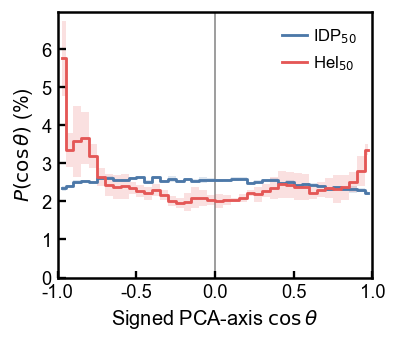

In [4]:
plot_cos_distribution(histogram)

## Figure 2 — Axially aligned pairs

This replaces the pooled probability-density plot. The y-axis is now the
percentage of directly NAC-contacting pairs with $|\cos	heta|\geq0.5$.

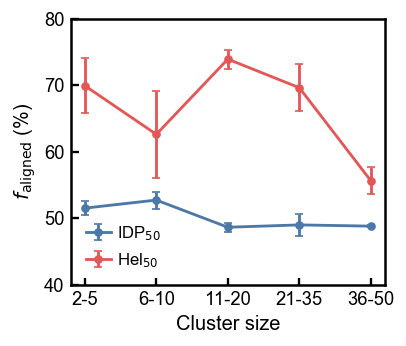

In [5]:
plot_metric(
    "mean_aligned_fraction_pct",
    "sem_aligned_fraction_pct",
    r"$f_{\mathrm{aligned}}$ (%)",
    "02_axially_aligned_pairs",
    ylim=(40, 80),
)

## Figure 3 — Broad anti-diagonal contact preference

Positive values mean that the broad anti-diagonal band is stronger than the
parallel band; negative values indicate the opposite.

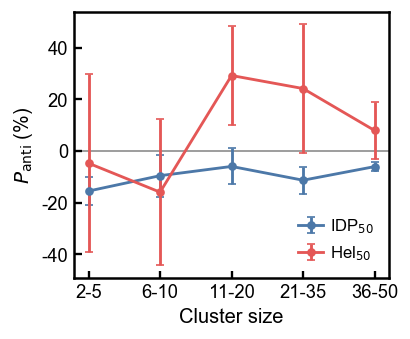

In [6]:
plot_metric(
    "mean_anti_diagonal_preference_pct",
    "sem_anti_diagonal_preference_pct",
    r"$P_{\mathrm{anti}}$ (%)",
    "03_anti_diagonal_preference",
    reference=0,
)

## Interpretation guide

- Figure 1 shows whether alignment is parallel, antiparallel, or mixed.
- Figure 2 establishes whether helices promote axial organization.
- The table distinguishes antiparallel bias from direction-neutral alignment.
- Figure 3 independently tests whether the contact-map registry favors the
  broad anti-diagonal band.

The results show association, not causation. The three trajectory means—not
individual chain-pair observations—are the statistical replicates.